# Loan Default Prediction MLOps Project
## Section 1 Setup & Imports

In [19]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# MLflow tracking
mlflow.set_tracking_uri('./mlruns')

# Paths
DATA_PATH = 'data/Loan_Data.csv'
MODEL_DIR = 'models/'
os.makedirs(MODEL_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


## Section 2 Exploratory Data Analysis

In [20]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print()
print(df.dtypes)
print()
df.head()

Shape: (10000, 8)

customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object



,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [21]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


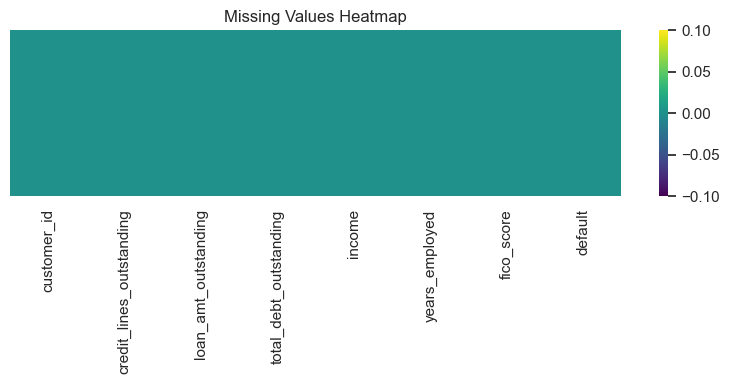

In [22]:
# Null-value heatmap
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

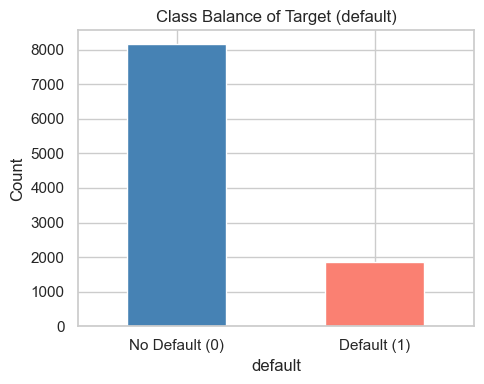

In [23]:
# Class balance
fig, ax = plt.subplots(figsize=(5, 4))
df['default'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Class Balance of Target (default)')
ax.set_xlabel('default')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
plt.tight_layout()
plt.show()

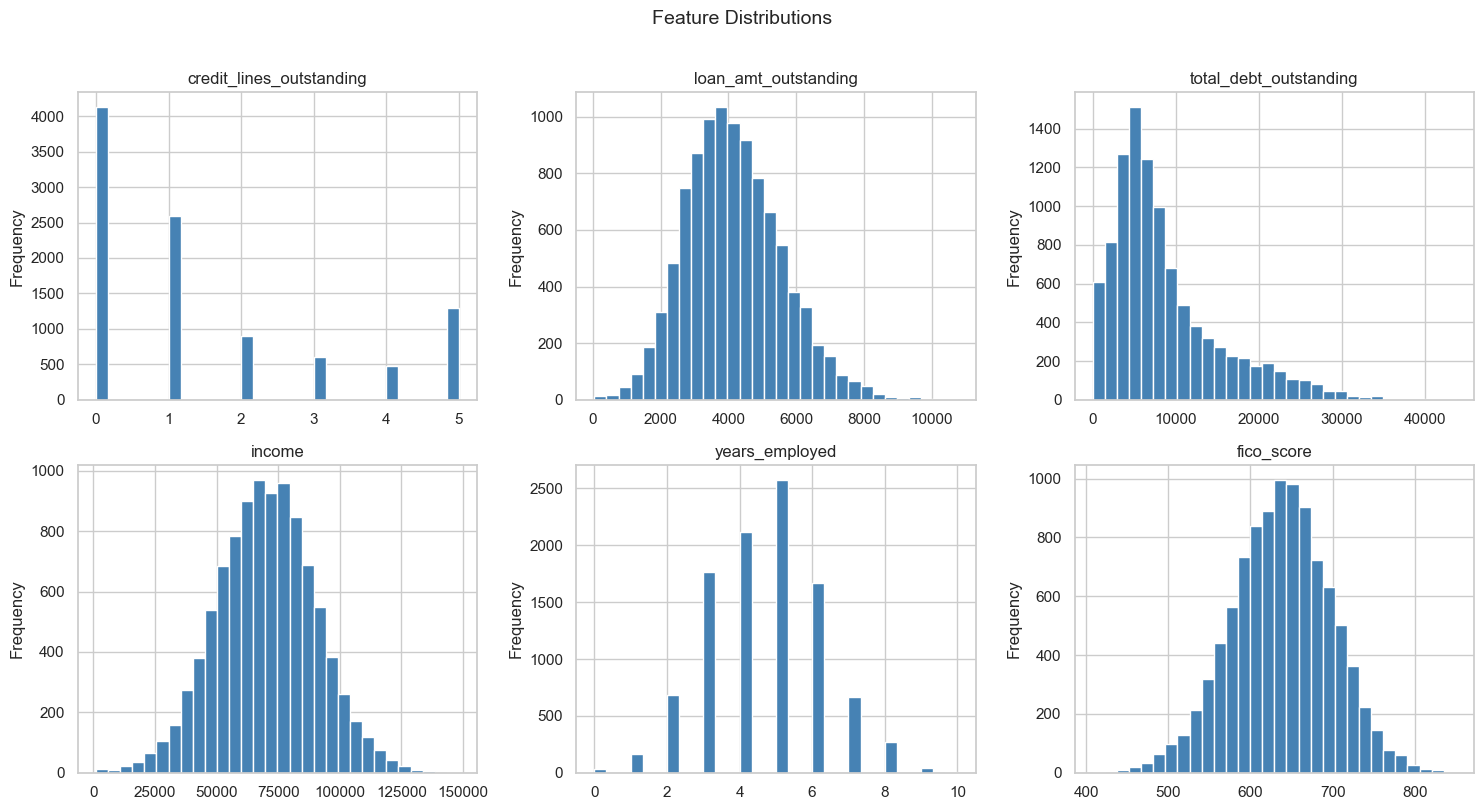

In [24]:
# Feature distributions (2x3 grid)
features = ['credit_lines_outstanding', 'loan_amt_outstanding',
            'total_debt_outstanding', 'income', 'years_employed', 'fico_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(features):
    ax = axes[i // 3, i % 3]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Frequency')
plt.suptitle('Feature Distributions', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

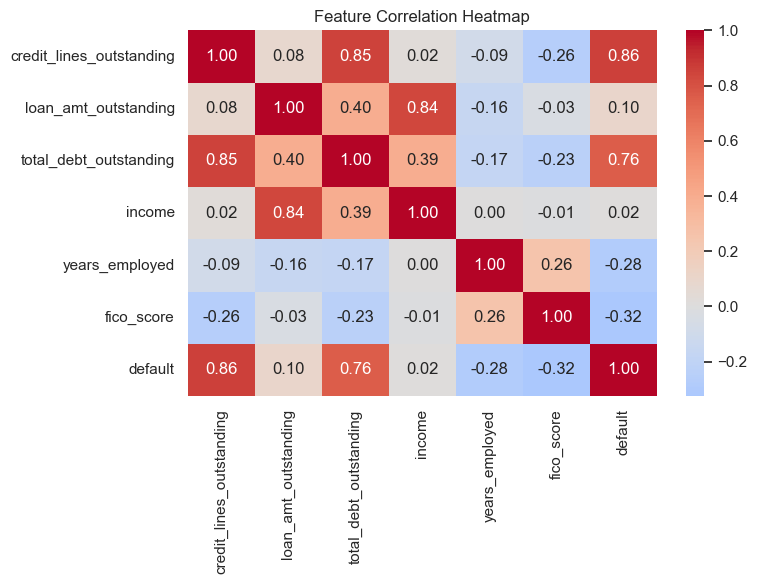

In [25]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df.drop(columns=['customer_id']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Section 3 Preprocessing

In [26]:
# Separate features and target
X = df.drop(columns=['default'])
y = df['default']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Save scaler
joblib.dump(scaler, MODEL_DIR + 'scaler.pkl')

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Scaler saved to {MODEL_DIR}scaler.pkl')

Train shape: (8000, 7)
Test shape:  (2000, 7)
Scaler saved to models/scaler.pkl
